What is XGBoost?

XGBoost is a Learning algorithm designed with speed and performance in mind. XGBoost stands for eXtreme Gradient Boosting and is based on decision trees. Here, we will import the XGBClassifier from the xgboost library; this is an implementation of the scikit-learn API for XGBoost classification.



In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In this notebook, we will use XGBoost to increase accuracy while decreasing the number of the code lines.

In [4]:
### importing Libraries
import numpy as np
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [5]:
#DataFlair - Read the data
df=pd.read_csv('parkinsons.data')
df.head()


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


Get the features and labels from the DataFrame (dataset). The features are all the columns except ‘status’, and the labels are those in the ‘status’ column.

In [6]:
#DataFlair - Get the features and labels
features=df.loc[:,df.columns!='status'].values[:,1:]
labels=df.loc[:,'status'].values

The ‘status’ column has values 0 and 1 as labels; let’s get the counts of these labels for both- 0 and 1.

In [7]:
#DataFlair - Get the count of each label (0 and 1) in labels
print(labels[labels==1].shape[0], labels[labels==0].shape[0])

147 48


We have 147 ones and 48 zeros in the status column in our dataset.

## Exploratory visualizations (before modeling)
These plots help us inspect data quality, class balance, and feature separation before training XGBoost.


In [12]:
# Quick dataset overview
print(f'Dataset shape: {df.shape}')
print('Columns:')
print(df.columns.tolist())
print('\nMissing values per column:')
print(df.isnull().sum())


Dataset shape: (195, 24)
Columns:
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Missing values per column:
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64


C:\Users\aliat\AppData\Local\Temp\ipykernel_22956\2101846276.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=status_labels, y=status_counts.values, palette=['#4C78A8', '#F58518'])


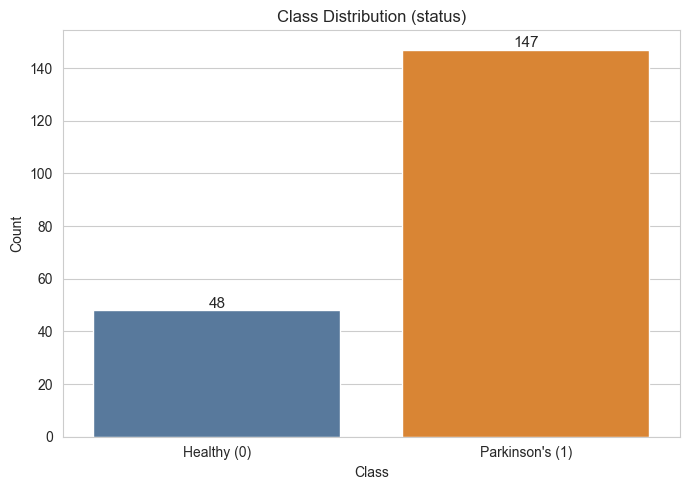

In [13]:
# Class distribution plot
status_counts = pd.Series(labels).value_counts().sort_index()
status_labels = ['Healthy (0)', "Parkinson's (1)"]

plt.figure(figsize=(7,5))
ax = sns.barplot(x=status_labels, y=status_counts.values, palette=['#4C78A8', '#F58518'])
for i, v in enumerate(status_counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontsize=11)
plt.title('Class Distribution (status)')
plt.ylabel('Count')
plt.xlabel('Class')
plt.tight_layout()
plt.show()


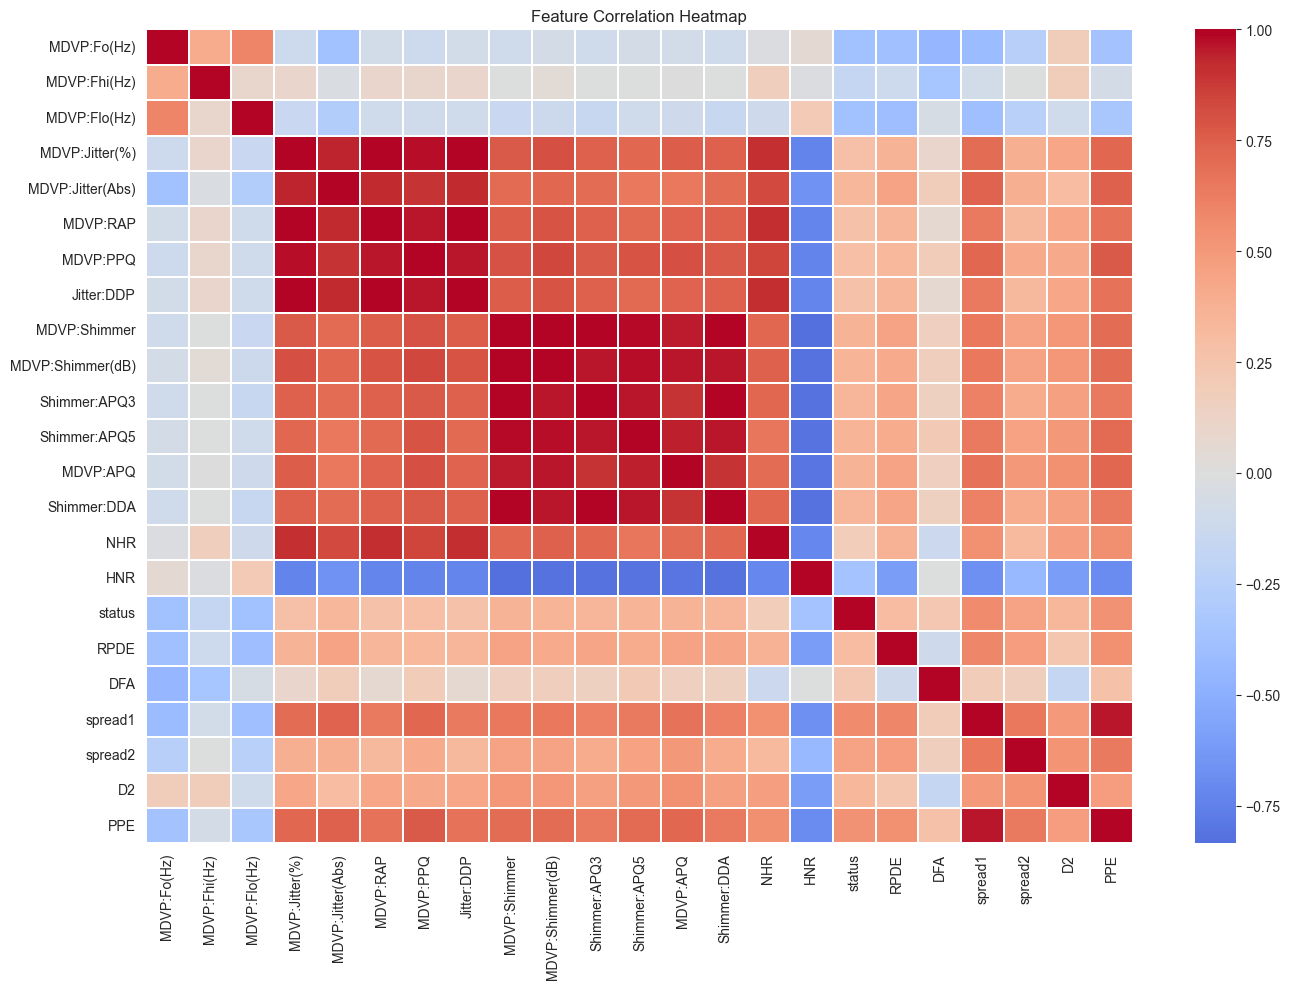

In [14]:
# Correlation heatmap for numeric features
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


C:\Users\aliat\AppData\Local\Temp\ipykernel_22956\232730702.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='status', y=feat, ax=axes[i], palette=['#4C78A8', '#F58518'])
C:\Users\aliat\AppData\Local\Temp\ipykernel_22956\232730702.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='status', y=feat, ax=axes[i], palette=['#4C78A8', '#F58518'])
C:\Users\aliat\AppData\Local\Temp\ipykernel_22956\232730702.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='status', y=feat, ax=axes[i], palette=[

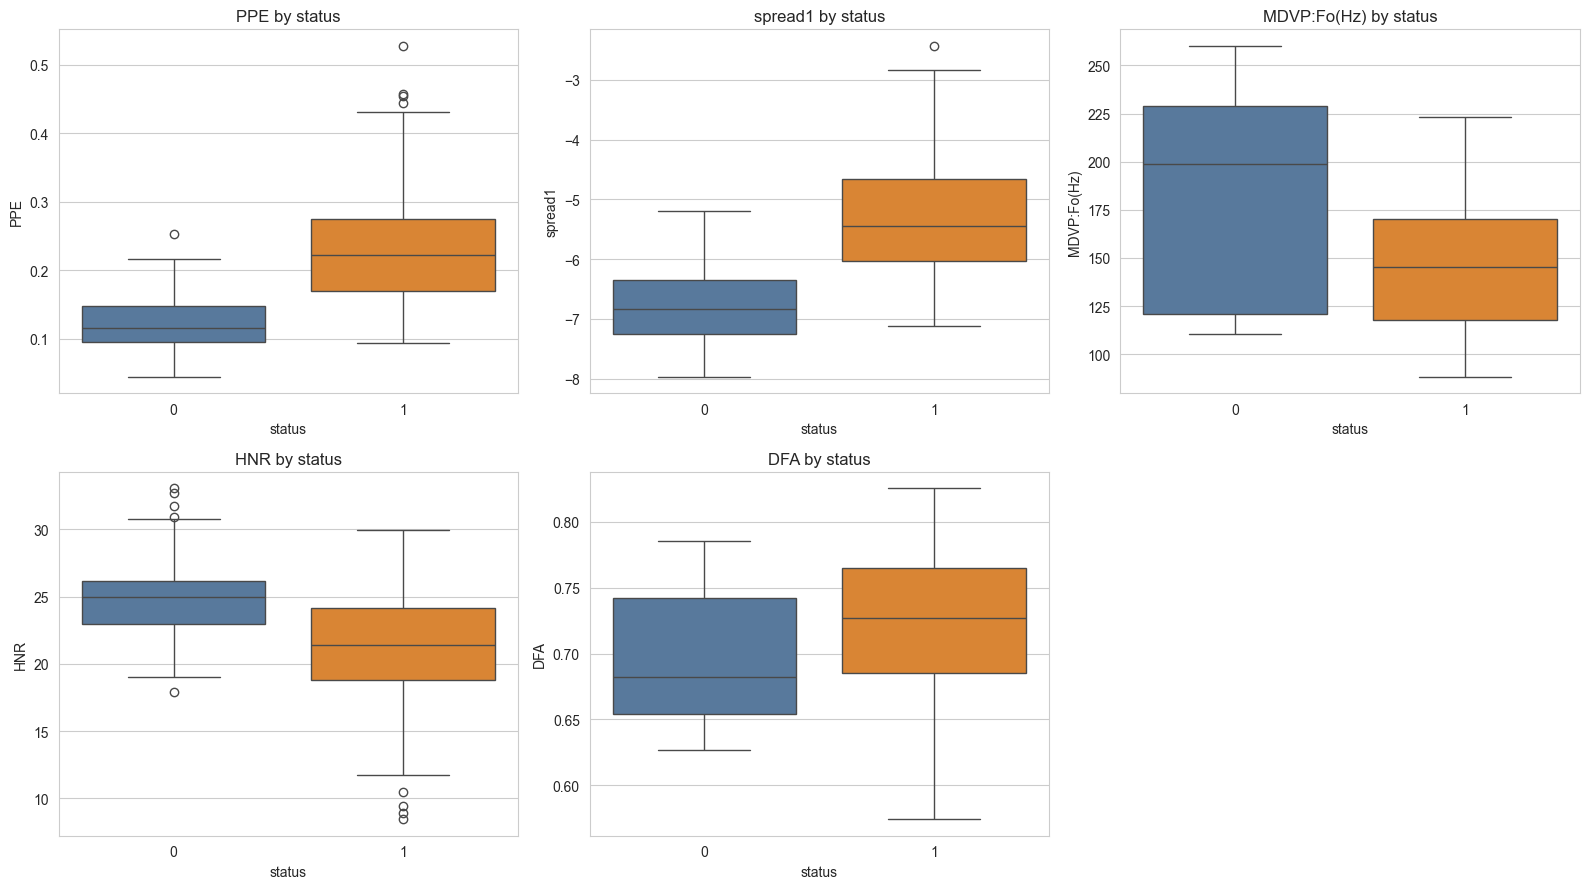

In [15]:
# Boxplots for selected high-signal features vs status
selected_features = ['PPE', 'spread1', 'MDVP:Fo(Hz)', 'HNR', 'DFA']
plot_df = df[selected_features + ['status']].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, feat in enumerate(selected_features):
    sns.boxplot(data=plot_df, x='status', y=feat, ax=axes[i], palette=['#4C78A8', '#F58518'])
    axes[i].set_title(f'{feat} by status')
    axes[i].set_xlabel('status')
for j in range(len(selected_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


Initialize a MinMaxScaler and scale the features to between -1 and 1 to normalize them. The MinMaxScaler transforms features by scaling them to a given range. The fit_transform() method fits to the data and then transforms it. We don’t need to scale the labels.

In [8]:
#DataFlair - Scale the features to between -1 and 1
scaler=MinMaxScaler((-1,1))
x=scaler.fit_transform(features)
y=labels

Now, split the dataset into training and testing sets keeping 20% of the data for testing.

In [9]:
#DataFlair - Split the dataset
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.2, random_state=7)

Initialize an XGBClassifier and train the model. This classifies using eXtreme Gradient Boosting-uses gradient boosting algorithms. It falls under the category of Ensemble Learning in ML, where we train and predict using many models to produce one superior output.

In [10]:
#DataFlair - Train the model
model=XGBClassifier()
model.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Generate predictions on the test set and report accuracy, precision, recall, and F1-score.


In [11]:
# DataFlair - Calculate evaluation metrics
y_pred=model.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc*100:.2f}%')

report_dict = classification_report(y_test, y_pred, output_dict=True)
precision = report_dict['1']['precision']
recall = report_dict['1']['recall']
f1 = report_dict['1']['f1-score']
print(f'Precision (class 1): {precision:.4f}')
print(f'Recall (class 1): {recall:.4f}')
print(f'F1-score (class 1): {f1:.4f}')


94.87179487179486


As you see, this gives us an accuracy of 94.87%, which is great considering the number of lines of code in this python notebook.

## Post-model diagnostics
These visualizations require predictions from the trained model.


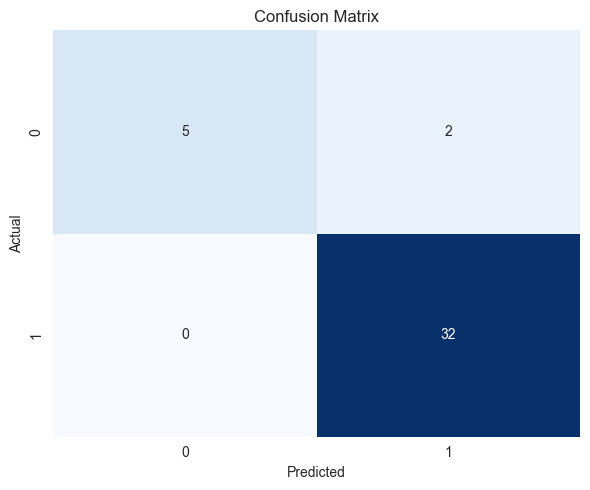

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.7143    0.8333         7
           1     0.9412    1.0000    0.9697        32

    accuracy                         0.9487        39
   macro avg     0.9706    0.8571    0.9015        39
weighted avg     0.9517    0.9487    0.9452        39



In [16]:
# Model diagnostics: confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_test, y_pred, digits=4))


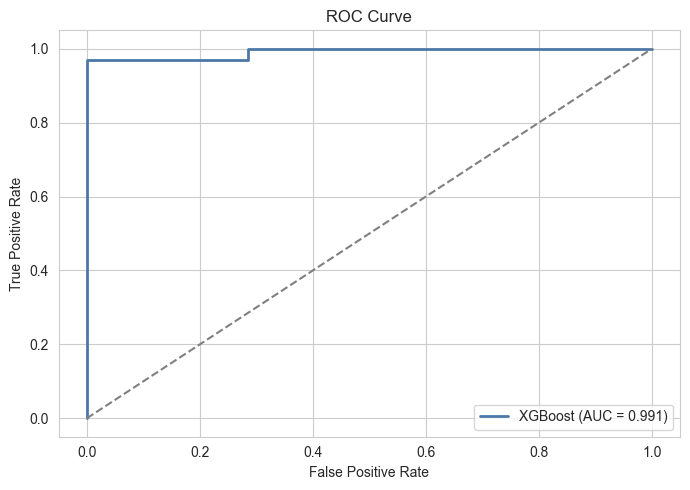

In [17]:
# ROC curve and AUC
y_proba = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})', color='#4C78A8', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


C:\Users\aliat\AppData\Local\Temp\ipykernel_22956\2791414485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index, palette='viridis')


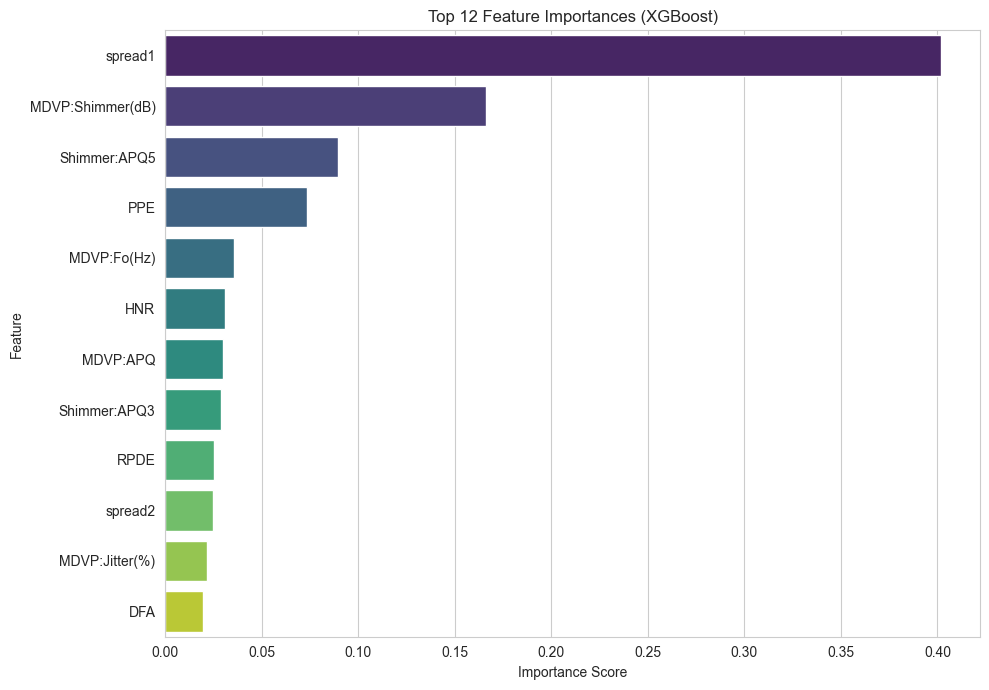

In [18]:
# Feature importance from XGBoost
feature_names = df.loc[:, df.columns != 'status'].columns[1:]
importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
top_n = 12

plt.figure(figsize=(10,7))
sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index, palette='viridis')
plt.title(f'Top {top_n} Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
